In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

print(tf.__version__)

2.19.0


In [5]:
import os

print(os.listdir('/kaggle/input/datasets'))

['alessiocorrado99']


In [4]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
DATASET_PATH = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img"

classes = os.listdir(dataset_path)

counts = []

for c in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path, c))))

df = pd.DataFrame({
    "Class": classes,
    "Images": counts
})

df

,Class,Images
0,cavallo,2623
1,pecora,1820
2,elefante,1446
3,gatto,1668
4,scoiattolo,1862
5,gallina,3098
6,ragno,4821
7,mucca,1866
8,cane,4863
9,farfalla,2112


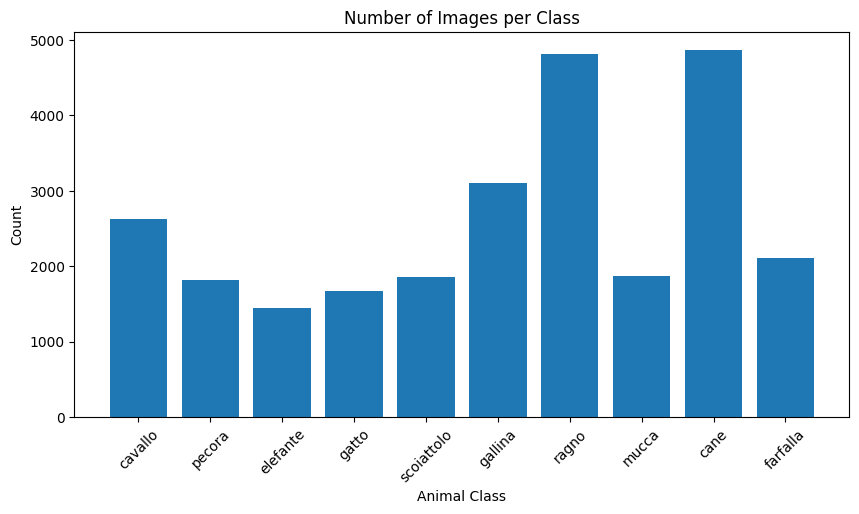

In [3]:
plt.figure(figsize=(10,5))
plt.bar(df["Class"], df["Images"])

plt.title("Number of Images per Class")
plt.xlabel("Animal Class")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

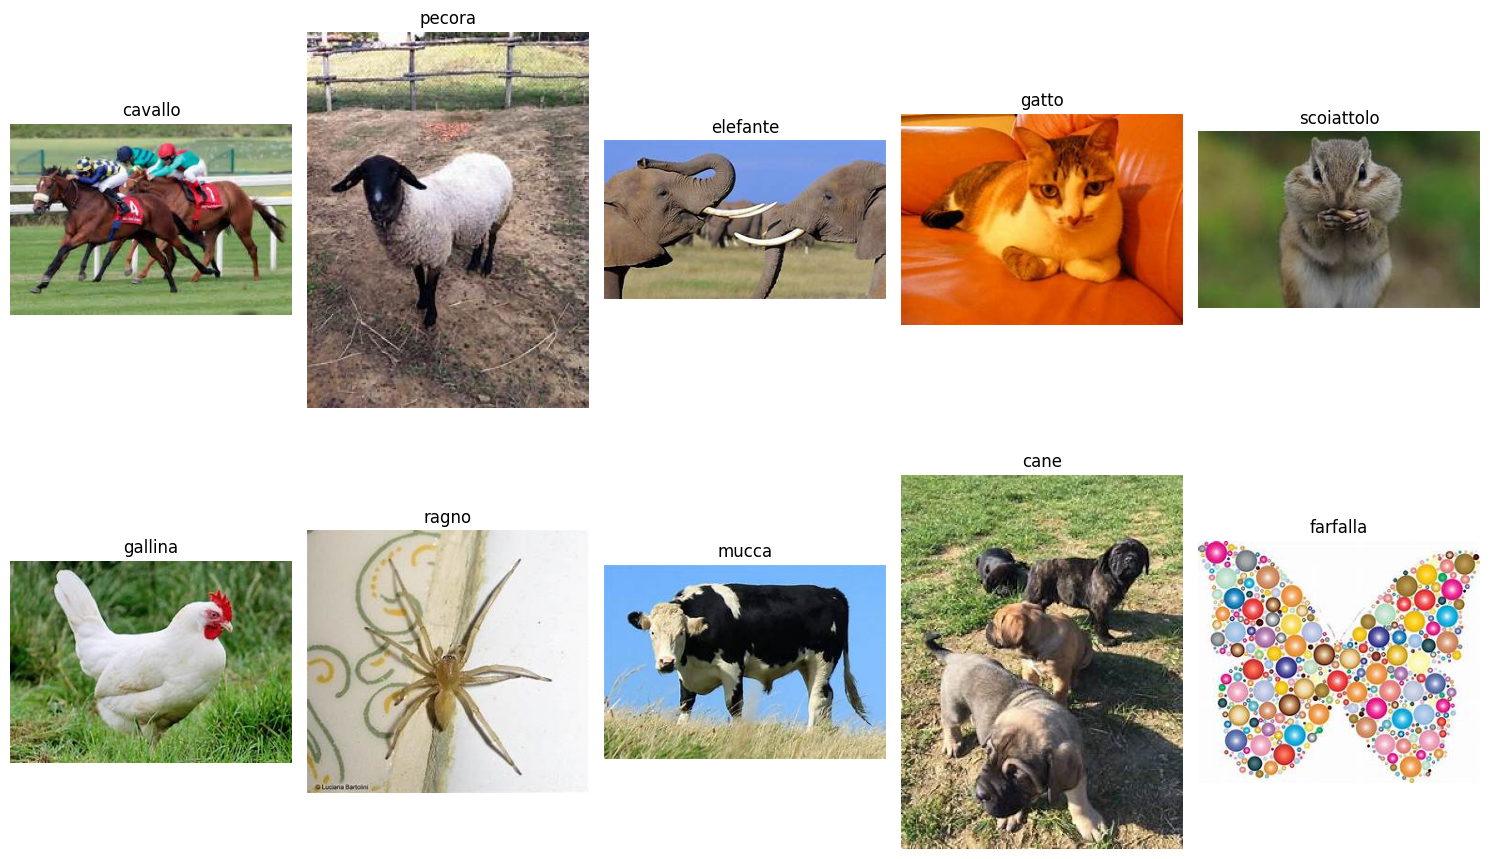

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(15,10))

for i, animal in enumerate(classes[:10]):

    folder = os.path.join(dataset_path, animal)
    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(animal)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.


In [53]:
import json

with open("classes.json", "w") as f:
    json.dump(train_generator.class_indices, f)

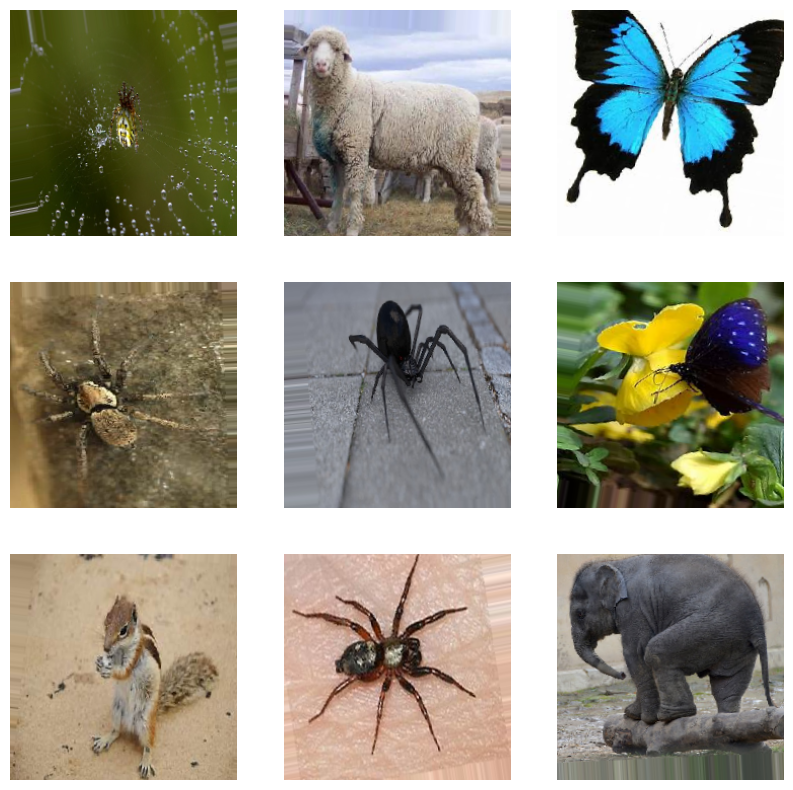

In [28]:
images, labels = next(train_generator)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [32]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
    ])

In [34]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)

In [37]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=12,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 304s 456ms/step - accuracy: 0.2673 - loss: 2.4882 - val_accuracy: 0.4253 - val_loss: 1.7308 - learning_rate: 1.0000e-04
Epoch 2/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 295s 450ms/step - accuracy: 0.3663 - loss: 1.8447 - val_accuracy: 0.4704 - val_loss: 1.5990 - learning_rate: 1.0000e-04
Epoch 3/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 295s 451ms/step - accuracy: 0.4252 - loss: 1.6934 - val_accuracy: 0.4815 - val_loss: 1.5046 - learning_rate: 1.0000e-04
Epoch 4/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 292s 446ms/step - accuracy: 0.4460 - loss: 1.6395 - val_accuracy: 0.5310 - val_loss: 1.3692 - learning_rate: 1.0000e-04
Epoch 5/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 291s 445ms/step - accuracy: 0.4781 - loss: 1.5286 - val_accuracy: 0.5669 - val_loss: 1.2645 - learning_rate: 1.0000e-04
Epoch 6/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 292s 446ms/step - accuracy: 0.5000 - loss: 1.4713 - val_accuracy: 0.5463 - val_loss: 1.4580 - learning_rate: 1.0000e-04
Epoch 7/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [38]:
validation_generator.reset()

pred = cnn_model.predict(validation_generator)
y_pred = np.argmax(pred, axis=1)
y_true = validation_generator.classes

labels = list(train_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

164/164 ━━━━━━━━━━━━━━━━━━━━ 57s 346ms/step
              precision    recall  f1-score   support

        cane       0.62      0.67      0.65       972
     cavallo       0.55      0.69      0.61       524
    elefante       0.50      0.62      0.56       289
    farfalla       0.70      0.82      0.75       422
     gallina       0.70      0.71      0.71       619
       gatto       0.71      0.25      0.37       333
       mucca       0.50      0.43      0.46       373
      pecora       0.56      0.49      0.52       364
       ragno       0.77      0.80      0.79       964
  scoiattolo       0.60      0.48      0.53       372

    accuracy                           0.64      5232
   macro avg       0.62      0.60      0.59      5232
weighted avg       0.64      0.64      0.63      5232



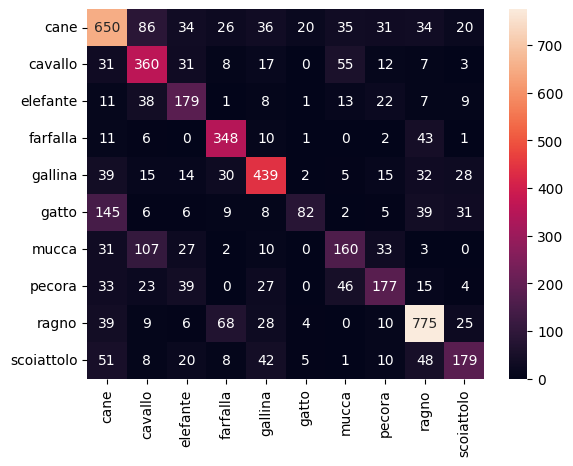

In [39]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.show()

In [40]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
])

In [44]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=7,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/7


2026-05-22 01:48:56.283979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 01:48:56.421096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


605/655 ━━━━━━━━━━━━━━━━━━━━ 19s 382ms/step - accuracy: 0.6164 - loss: 1.2521

2026-05-22 01:52:58.324773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 01:52:58.461765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6292 - loss: 1.2122

2026-05-22 01:54:30.677716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 01:54:30.814688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


655/655 ━━━━━━━━━━━━━━━━━━━━ 351s 511ms/step - accuracy: 0.6294 - loss: 1.2114 - val_accuracy: 0.9297 - val_loss: 0.2395 - learning_rate: 1.0000e-04
Epoch 2/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 298s 455ms/step - accuracy: 0.9076 - loss: 0.3150 - val_accuracy: 0.9406 - val_loss: 0.1935 - learning_rate: 1.0000e-04
Epoch 3/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 295s 450ms/step - accuracy: 0.9301 - loss: 0.2426 - val_accuracy: 0.9459 - val_loss: 0.1729 - learning_rate: 1.0000e-04
Epoch 4/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 295s 451ms/step - accuracy: 0.9328 - loss: 0.2179 - val_accuracy: 0.9442 - val_loss: 0.1692 - learning_rate: 1.0000e-04
Epoch 5/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 290s 443ms/step - accuracy: 0.9331 - loss: 0.2126 - val_accuracy: 0.9497 - val_loss: 0.1594 - learning_rate: 1.0000e-04
Epoch 6/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 293s 448ms/step - accuracy: 0.9444 - loss: 0.1779 - val_accuracy: 0.9490 - val_loss: 0.1563 - learning_rate: 1.0000e-04
Epoch 7/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 293s 448ms/step -

In [46]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes, activation='softmax')
])

In [49]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=7,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 325s 477ms/step - accuracy: 0.1777 - loss: 2.2888 - val_accuracy: 0.2460 - val_loss: 2.1373 - learning_rate: 1.0000e-04
Epoch 2/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 297s 453ms/step - accuracy: 0.2271 - loss: 2.1487 - val_accuracy: 0.2456 - val_loss: 2.1059 - learning_rate: 1.0000e-04
Epoch 3/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 299s 457ms/step - accuracy: 0.2477 - loss: 2.1229 - val_accuracy: 0.2867 - val_loss: 2.0742 - learning_rate: 1.0000e-04
Epoch 4/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 302s 461ms/step - accuracy: 0.2637 - loss: 2.0984 - val_accuracy: 0.2991 - val_loss: 2.0542 - learning_rate: 1.0000e-04
Epoch 5/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 298s 454ms/step - accuracy: 0.2669 - loss: 2.0748 - val_accuracy: 0.2857 - val_loss: 2.0352 - learning_rate: 1.0000e-04
Epoch 6/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 301s 459ms/step - accuracy: 0.2827 - loss: 2.0556 - val_accuracy: 0.3052 - val_loss: 2.0133 - learning_rate: 1.0000e-04
Epoch 7/7
655/655 ━━━━━━━━━━━━━━━━━━━━ 301s 46

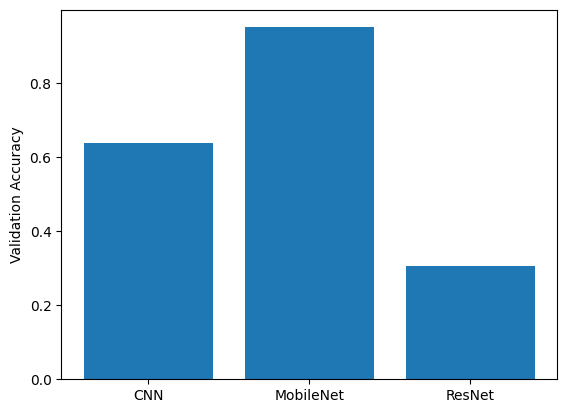

In [51]:
cnn_acc = max(cnn_history.history['val_accuracy'])
mob_acc = max(mobilenet_history.history['val_accuracy'])
res_acc = max(resnet_history.history['val_accuracy'])

plt.bar(['CNN','MobileNet','ResNet'], [cnn_acc,mob_acc,res_acc])
plt.ylabel("Validation Accuracy")
plt.show()

In [56]:
mobilenet_model.save("/kaggle/working/best_model.keras")

In [58]:
import shutil

shutil.copy(
    "/kaggle/working/best_model.keras",
    "/kaggle/working/model.keras"
)

'/kaggle/working/model.keras'

In [61]:
from IPython.display import FileLink

FileLink("/kaggle/working/model.keras")

/kaggle/working/model.keras

In [67]:
import shutil

shutil.make_archive("model", "zip", "/kaggle/working", "")

'/kaggle/working/model.zip'

In [68]:
from IPython.display import FileLink

FileLink("model.zip")

/kaggle/working/model.zip